# Data exploration

## Dataset

Dataset is categorical data of student performance based on numerous factors. In this I will be taking all these factors and training them on an XG Boost model

In [351]:
### Loading the Dataset

In [352]:
import pandas as pd

#Reading file
df = pd.read_csv("StudentPerformanceFactors - StudentPerformanceFactors.csv")
df.columns

#Shows the how much rows and the mean of each numerical category
df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [353]:
# How many rows are null
df.isna().any(axis=1).sum()

np.int64(229)

In [354]:
#Missing data might cause issues in our model
#We also can't drop the rows with missing data, as these could be special cases
#To determine if we can drop, we can do summary stats, of the parts with the missing data,
#compare the mean and see, if it's that big of a difference

#Checks creates a missing row mask
missing_rows_mask = df.isnull().any(axis=1)

#DF with only rows with missing values
missing_na_df = df[missing_rows_mask]

#DF without rows with missing values
no_missing_na_df = df[~missing_rows_mask]



In [355]:
#Summary stats of data with missing values
no_missing_na_df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,7.034964,75.066165,1.495296,2.972719,67.252117
std,5.985460,11.550723,1.468033,14.400389,1.233984,1.028926,3.914217
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,101.000000


In [356]:
#Summary stats of data without missing values
missing_na_df.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000
mean,19.925764,78.768559,6.864629,75.192140,1.449782,2.825328,66.777293
std,6.145080,11.415351,1.464198,14.413923,1.132983,1.086224,3.129964
min,2.000000,60.000000,4.000000,50.000000,0.000000,0.000000,58.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,78.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,89.000000,8.000000,88.000000,2.000000,3.000000,69.000000
max,39.000000,100.000000,10.000000,100.000000,5.000000,6.000000,74.000000


In [357]:
#Extract the mean columns from the summary stats
avg_missing = missing_na_df.describe().loc['mean']
avg_clean = no_missing_na_df.describe().loc['mean']

#Creating a dataframe with missing row values and complete rows mean to visualize the plot data
comparison_df = pd.DataFrame({
    'Variable': avg_missing.index,
    'Rows_with_Missing_Data': avg_missing.values,
    'Complete_Rows': avg_clean.values
})

#Creating a plotly plot
plot_data = comparison_df.melt(id_vars='Variable', 
                               var_name='Group', 
                               value_name='Mean_Value')
fig = px.bar(plot_data, 
             x='Variable', 
             y='Mean_Value', 
             color='Group', 
             barmode='group',
             title='Bias Check: Mean Values of Complete vs. Incomplete Cases',
             template='plotly_white')

fig.show()

### One Hot Encoding
The first step, is that our data has categories. The problem with these categories is that they are not necessary or inherently ordered. For example, gender is not ordered males dont come before female and vice versa.

However, we have some data which says high, medium, low. This while not represented numerically can be represented as values



In [358]:
#Show the columns and see separte data to be ordinal and one hot encoded
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [359]:
#These are the columns which are not ordered so we can use one hot encoding
ohe_columns = ['Internet_Access', 'Gender', 'Learning_Disabilities','Extracurricular_Activities', 'School_Type']

#Store original columns before one-hot encoding
original_cols_to_keep = df.columns

#One hot encode these columns
data_encoding = pd.get_dummies(df, columns = ohe_columns, drop_first=True)

new_ohe_column_names = data_encoding.columns.difference(original_cols_to_keep)

data_encoding[new_ohe_column_names]= data_encoding[new_ohe_column_names].astype(int)

data_encoding.head(50)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Internet_Access_Yes,Gender_Male,Learning_Disabilities_Yes,Extracurricular_Activities_Yes,School_Type_Public
0,23,84,Low,High,7,73,Low,0,Low,Medium,Positive,3,High School,Near,67,1,1,0,0,1
1,19,64,Low,Medium,8,59,Low,2,Medium,Medium,Negative,4,College,Moderate,61,1,0,0,0,1
2,24,98,Medium,Medium,7,91,Medium,2,Medium,Medium,Neutral,4,Postgraduate,Near,74,1,1,0,1,1
3,29,89,Low,Medium,8,98,Medium,1,Medium,Medium,Negative,4,High School,Moderate,71,1,1,0,1,1
4,19,92,Medium,Medium,6,65,Medium,3,Medium,High,Neutral,4,College,Near,70,1,0,0,1,1
5,19,88,Medium,Medium,8,89,Medium,3,Medium,Medium,Positive,3,Postgraduate,Near,71,1,1,0,1,1
6,29,84,Medium,Low,7,68,Low,1,Low,Medium,Neutral,2,High School,Moderate,67,1,1,0,1,0
7,25,78,Low,High,6,50,Medium,1,High,High,Negative,2,High School,Far,66,1,1,0,1,1
8,17,94,Medium,High,6,80,High,0,Medium,Low,Neutral,1,College,Near,69,1,1,0,0,0
9,23,98,Medium,Medium,8,71,Medium,0,High,High,Positive,5,High School,Moderate,72,1,1,0,1,1


### Ordinal Encoding

In [360]:
#Define columns we want to use ordinal encoding on

columns_to_encode = ['Access_to_Resources', 'Motivation_Level' ,'Teacher_Quality', 'Parental_Involvement', 'Parental_Education_Level', 'Peer_Influence', 'Family_Income', 'Distance_from_Home']

#Set the orders of the categories that exist
order_0 = ['Low', 'Medium', 'High']
order_1 = ['Negative', 'Neutral', 'Positive']
order_2 = ['High School', 'College', 'Postgraduate']
order_3 = ['Near', 'Moderate', 'Far']

#Create list of columns which map to the orders mentioned above
columns_0 = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality']
columns_1 = ['Peer_Influence']
columns_2 = ['Parental_Education_Level']
columns_3 = ['Distance_from_Home']

#Columns 0 Ordinal Encdoing
for column in columns_0:
    data_encoding[column] = pd.Categorical(data_encoding[column], categories= order_0, ordered= True)
    encoded_column_name = column
    data_encoding[encoded_column_name] = data_encoding[column].cat.codes

#Columns 1 Ordinal Encdoing
for column in columns_1:
    data_encoding[column] = pd.Categorical(data_encoding[column], categories= order_1, ordered= True)
    encoded_column_name = column
    data_encoding[encoded_column_name] = data_encoding[column].cat.codes

#Columns 2 Ordinal Encdoing
for column in columns_2:
    data_encoding[column] = pd.Categorical(data_encoding[column], categories= order_2, ordered= True)
    encoded_column_name = column 
    data_encoding[encoded_column_name] = data_encoding[column].cat.codes

#Columns 3 Ordinal Encdoing
for column in columns_3:
    data_encoding[column] = pd.Categorical(data_encoding[column], categories= order_3, ordered= True)
    encoded_column_name = column
    data_encoding[encoded_column_name] = data_encoding[column].cat.codes

data_encoding.head(50)



,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Internet_Access_Yes,Gender_Male,Learning_Disabilities_Yes,Extracurricular_Activities_Yes,School_Type_Public
0,23,84,0,2,7,73,0,0,0,1,2,3,0,0,67,1,1,0,0,1
1,19,64,0,1,8,59,0,2,1,1,0,4,1,1,61,1,0,0,0,1
2,24,98,1,1,7,91,1,2,1,1,1,4,2,0,74,1,1,0,1,1
3,29,89,0,1,8,98,1,1,1,1,0,4,0,1,71,1,1,0,1,1
4,19,92,1,1,6,65,1,3,1,2,1,4,1,0,70,1,0,0,1,1
5,19,88,1,1,8,89,1,3,1,1,2,3,2,0,71,1,1,0,1,1
6,29,84,1,0,7,68,0,1,0,1,1,2,0,1,67,1,1,0,1,0
7,25,78,0,2,6,50,1,1,2,2,0,2,0,2,66,1,1,0,1,1
8,17,94,1,2,6,80,2,0,1,0,1,1,1,0,69,1,1,0,0,0
9,23,98,1,1,8,71,1,0,2,2,2,5,0,1,72,1,1,0,1,1


# Training the model

In [361]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

#Extract xvalues, which is anything but our target output(Exam_Score)
X = data_encoding.drop('Exam_Score', axis=1)
y = data_encoding['Exam_Score']


In [ ]:
#Splitting our data set into test set and training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror'
    learning_rate=0.1,           
    max_depth=5,                 
    random_state=42
)

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
rmse_scores = -cv_scores

print(f"Cross-Validation RMSE Scores: {rmse_scores}")
print(f"Average RMSE across 5 folds: {rmse_scores.mean():.2f}")

Cross-Validation RMSE Scores: [1.80187142 1.87430263 2.16084194 2.26357126 2.93237662]
Average RMSE across 5 folds: 2.21


In [364]:
rmse_scores = [1.80187142 ,1.87430263, 2.16084194, 2.26357126, 2.93237662]
num_folds = len(rmse_scores)

# Create a DataFrame for plotting
df_cv_results = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(num_folds)],
    'RMSE': rmse_scores,
    'Average_RMSE': [pd.Series(rmse_scores).mean()] * num_folds
})

# Create the Plotly bar chart
fig = px.bar(
    df_cv_results,
    x='Fold',
    y='RMSE',
    title='Cross-Validation Performance (RMSE per Fold)',
    labels={'RMSE': 'Root Mean Squared Error'},
    text='RMSE',
)
fig.show()

In [365]:
fig = px.bar(rmse_scores, 
             x='Variable', 
             y='Mean_Value', 
             color='Group', 
             barmode='group',
             title='Bias Check: Mean Values of Complete vs. Incomplete Cases',
             template='plotly_white')

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of [0] but received: Variable

In [ ]:
import numpy as np


xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
final_predictions = xgb_model.predict(X_test)
final_rmse = mean_squared_error(y_test, final_predictions) # squared=False returns RMSE
final_rmse = np.sqrt(final_rmse)

print(f"Final Test Set RMSE: {final_rmse:.2f}")

Final Test Set RMSE: 0.04


In [ ]:
import plotly.express as px
import pandas as pd

# 1. Generate predictions on the Training Set
y_train_pred = xgb_model.predict(X_train)

# 2. Organize data into a DataFrame for Plotly
train_plot_data = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})

# 3. Create the Interactive Scatter Plot
fig = px.scatter(
    train_plot_data, 
    x='Actual', 
    y='Predicted',
    title='Actual vs. Predicted Scores (Training Set)',
    labels={'Actual': 'Actual Exam Score', 'Predicted': 'Predicted Exam Score'},
    opacity=0.6,
    width=800,
    height=600
)

# 4. Add a red dashed diagonal line (The "Perfect Prediction" Line)
# If points fall exactly on this line, the prediction was perfect.
fig.add_shape(
    type="line",
    x0=y_train.min(), y0=y_train.min(),
    x1=y_train.max(), y1=y_train.max(),
    line=dict(color="Red", dash="dash"),
)

# Show the plot
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Generate predictions on the Test Set
y_test_pred = xgb_model.predict(X_test)

# 2. Organize data into a DataFrame for Plotly
test_plot_data = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

# 3. Create the Interactive Scatter Plot
fig = px.scatter(
    test_plot_data, 
    x='Actual', 
    y='Predicted',
    title='Actual vs. Predicted Scores (Test Set)',
    labels={'Actual': 'Actual Exam Score', 'Predicted': 'Predicted Exam Score'},
    opacity=0.6,
    width=800,
    height=600
)

# 4. Add the red dashed "Perfect Prediction" line
fig.add_shape(
    type="line",
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color="Red", dash="dash"),
)

# Show the plot
fig.show()

ValueError: Per-column arrays must each be 1-dimensional

In [ ]:
# Create a DataFrame with Actual, Predicted, and Error
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = final_predictions
results['Error'] = np.abs(results['Actual'] - results['Predicted'])

# Sort by the biggest "Under-Predictions" (Actual > Predicted)
misses = results.sort_values(by='Error', ascending=False)

mask = results['Error'] > 5

len(results[mask])

# misses.head(10)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

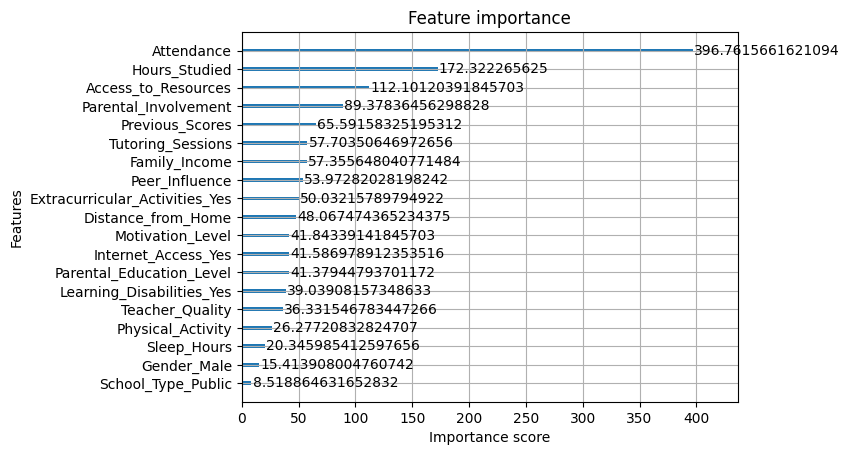

In [ ]:
xgb.plot_importance(xgb_model, importance_type="gain")


In [ ]:
importance = xgb_model.get_booster().get_score(importance_type='total_gain')

print(importance)

df = pd.DataFrame(importance.items(), columns=['Feature', 'Total_Gain'])

# Calculate the Sum
total_gain_sum = df['Total_Gain'].sum()

# Create a percentage column
df['Percentage'] = (df['Total_Gain'] / total_gain_sum) * 100

# Sort and display
df = df.sort_values(by='Percentage', ascending=False)


{'f0': 45.605159759521484, 'f1': 72.37713623046875, 'f2': 7.265148639678955, 'f3': 7.734804153442383, 'f4': 1.00960373878479, 'f5': 10.694290161132812, 'f6': 1.9972485303878784, 'f7': 5.890328884124756, 'f8': 3.1984846591949463, 'f9': 1.8886858224868774, 'f10': 2.729246139526367, 'f11': 2.0986950397491455, 'f12': 2.1511032581329346, 'f13': 1.9535940885543823, 'f14': 0.9433663487434387, 'f15': 0.11655133962631226, 'f16': 1.4206149578094482, 'f17': 1.2295236587524414, 'f18': 0.0885704979300499}


In [ ]:
import plotly.express as px


# Create the bar chart
fig = px.bar(df, 
             x='Percentage', 
             y='Feature', 
             orientation='h', # Horizontal bars
             title='Feature Importance',
             text='Percentage', # Show the values on the bars
             color='Percentage', # Optional: Color by value
             color_continuous_scale='Viridis'
            )

# Improvements for better readability:
# 1. Format the text label to 1 decimal place (e.g., "25.4%")
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')

# 2. Invert the Y-axis so the most important feature is at the TOP
# (Plotly's default puts the first row at the bottom)
fig.update_layout(yaxis=dict(autorange="reversed"))

fig.show()

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Physical_Activity', 'Parental_Education_Level', 'Distance_from_Home', 'Internet_Access_Yes', 'Gender_Male', 'Learning_Disabilities_Yes', 'Extracurricular_Activities_Yes', 'School_Type_Public']


In [ ]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),  # Pass numpy array
    feature_names=X_train.columns,
    class_names=['Malignant', 'Benign'],
    mode='regression'
)

# Select the 5th instance in the test set
i = 5
instance_to_explain = X_test.iloc[94]

# Generate explanation
# Note: We pass model.predict_proba as the prediction function
exp = explainer.explain_instance(
    data_row=instance_to_explain, 
    predict_fn=xgb_model.predict,
    num_features=5  # Show top 5 features
)

# Visualize in notebook
exp.show_in_notebook(show_table=True)

# OR print list of weights if not in a notebook
print(exp.as_list())

c:\Users\Nick-Uni\AppData\Local\Programs\Python\Python310\lib\site-packages\lime\discretize.py:110: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

c:\Users\Nick-Uni\AppData\Local\Programs\Python\Python310\lib\site-packages\lime\discretize.py:110: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`

c:\Users\Nick-Uni\AppData\Local\Programs\Python\Python310\lib\site-packages\lime\lime_tabular.py:544: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.ilo

[('Hours_Studied <= 16.00', -3.105079951215258), ('70.00 < Attendance <= 80.00', -1.1812744488038835), ('Tutoring_Sessions <= 1.00', -1.0477633604844208), ('Learning_Disabilities_Yes <= 0.00', 0.9670759244809572), ('0.00 < Extracurricular_Activities_Yes <= 1.00', 0.5960144152865765)]


In [ ]:
# Calculate correlation matrix
# We use the ORIGINAL (unscaled) X dataframe so we see the real relationships
corr_matrix = X.corr()

# Create a Heatmap
fig = px.imshow(corr_matrix,
                text_auto=True,
                aspect="auto",
                color_continuous_scale='RdBu_r', # Red-Blue diverging scale
                title="Feature Correlation Matrix"
               )
fig.show()